# Bringing the Heat — Forecasting-Oriented EDA

This notebook audits whether the data support a trustworthy **day-ahead grid-import forecast**. Every section ends in a forecasting decision: target definition, usable information, temporal signal, segmentation, validation, uncertainty, or leakage control.

**Operational target used here:** `kWh_received_Total`, the energy received from the grid in each 15-minute interval. There is no PV production or grid-export measurement, so this is not a direct generation forecast.

**Day-ahead contract (shared with every notebook, `utils.modeling.DAY_AHEAD`):** the 96 quarter-hours of UTC delivery day D are forecast from observations strictly before **10:00 UTC on D-1**, ahead of the 12:00 local EPEX day-ahead gate closure. Consequently the same slot on D-1 is only known for slots before 10:00 UTC; D-2 and older are always known.

In [1]:
from pathlib import Path
import gc
import sys
import time
import warnings

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'README.md').exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from utils import (
    add_exact_lags, build_hourly_panel, build_interval_panel, daily_meter_quality,
    load_household_metadata, load_weather_data, meter_gap_table, scan_meter_data,
    stable_cohort, temporal_baseline_predictions,
)

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.titleweight': 'bold'})
pd.set_option('display.max_columns', 40)
SEASON_ORDER = ['winter', 'spring', 'summer', 'autumn']
BASELINE_LABELS = {
    'prediction_previous_day': 'Previous day',
    'prediction_previous_week': 'Previous week',
    'prediction_historical_tod': 'Historical time-of-day',
}

## 1. Forecast contract and information availability

Before plotting, separate variables that are measured from variables genuinely known at forecast time.

In [2]:
availability_audit = pd.DataFrame([
    ('Calendar', 'Yes', 'Deterministic for the complete horizon.'),
    ('Past grid import', 'Yes, before cutoff', 'Create lags by exact timestamps; never compress gaps.'),
    ('Rolling demand statistics', 'Yes, if shifted', 'Every slot of day D uses only history before the 10:00 UTC D-1 cutoff.'),
    ('Realised target-day weather', 'No', 'Use weather forecasts in production; realised weather is an optimistic EDA proxy.'),
    ('Household/PV metadata', 'Usually', 'Static, but 165 PV labels and some survey fields are missing.'),
    ('Before/after intervention', 'Needs confirmation', 'Usable only if visit timing is recorded before forecast issuance.'),
    ('Future meter availability', 'No', 'The stable-cohort filter is an evaluation design, not a deployable feature.'),
], columns=['Candidate information', 'Known at forecast time?', 'Rule'])
display(availability_audit)

,Candidate information,Known at forecast time?,Rule
0,Calendar,Yes,Deterministic for the complete horizon.
1,Past grid import,"Yes, before cutoff",Create lags by exact timestamps; never compres...
2,Rolling demand statistics,"Yes, if shifted",Every slot of day D uses only history before t...
3,Realised target-day weather,No,Use weather forecasts in production; realised ...
4,Household/PV metadata,Usually,"Static, but 165 PV labels and some survey fiel..."
5,Before/after intervention,Needs confirmation,Usable only if visit timing is recorded before...
6,Future meter availability,No,The stable-cohort filter is an evaluation desi...


## 2. Dataset inventory and hard quality checks

The raw meter files contain two physical column orders; the shared loader normalizes them by column name. Quality checks below distinguish absent timestamps from present rows whose target value is null. UTC days are used for the expected 96 intervals, avoiding daylight-saving ambiguity.

In [3]:
started = time.perf_counter()
meter = scan_meter_data()
metadata = load_household_metadata()
weather = load_weather_data()

raw_summary = meter.select(
    pl.len().alias('rows'),
    pl.col('Household_ID').n_unique().alias('households'),
    pl.col('timestamp_utc').min().alias('start'),
    pl.col('timestamp_utc').max().alias('end'),
    pl.col('kWh_received_Total').null_count().alias('null_target_rows'),
    (pl.col('kWh_received_Total') < 0).sum().alias('negative_target_rows'),
    (pl.col('kWh_received_Total') == 0).sum().alias('zero_target_rows'),
    pl.col('kWh_received_Total').quantile(.999).alias('target_p999_kwh'),
    pl.col('kWh_received_Total').max().alias('target_max_kwh'),
).collect()
duplicates = (
    meter.group_by('Household_ID', 'timestamp_utc').len().filter(pl.col('len') > 1)
    .select(pl.len().alias('duplicate_timestamp_keys')).collect()
)
daily_quality = daily_meter_quality(meter)
gaps = meter_gap_table(meter)

weather_summary = weather.group_by('Weather_ID').agg(
    pl.len().alias('rows'), pl.col('timestamp_utc').min().alias('start'),
    pl.col('timestamp_utc').max().alias('end'),
    pl.col('Temperature_avg_hourly').null_count().alias('temperature_nulls'),
    pl.col('WindSpeed_hourly').null_count().alias('wind_nulls'),
).sort('Weather_ID')

quality_cards = pd.DataFrame({
    'Metric': ['Households', '15-minute rows', 'Expected intervals/day', 'Duplicate timestamp keys',
               'Observed UTC days', 'Complete UTC days', 'Rows with missing target',
               'Timestamp gaps', 'Weather stations', 'Metadata-complete households'],
    'Value': [raw_summary.item(0, 'households'), raw_summary.item(0, 'rows'), 96,
              duplicates.item(), daily_quality.height, daily_quality['day_complete'].sum(),
              raw_summary.item(0, 'null_target_rows'), gaps.height, weather['Weather_ID'].n_unique(),
              metadata['MetaData_Available'].sum()],
})
display(quality_cards)
display(weather_summary.to_pandas())
metadata_missing = (metadata.null_count().transpose(include_header=True, header_name='field', column_names=['missing'])
                    .filter(pl.col('missing') > 0).sort('missing', descending=True))
weather_missing = (weather.null_count().transpose(include_header=True, header_name='field', column_names=['missing'])
                   .filter(pl.col('missing') > 0).sort('missing', descending=True))
display(Markdown('**Most-missing metadata fields:**'))
display(metadata_missing.head(12).to_pandas())
display(Markdown('**Weather-variable missingness across all stations:**'))
display(weather_missing.to_pandas())
print(f'Initial quality audit: {time.perf_counter() - started:.1f}s')

,Metric,Value
0,Households,410
1,15-minute rows,28180608
2,Expected intervals/day,96
3,Duplicate timestamp keys,0
4,Observed UTC days,293548
5,Complete UTC days,288157
6,Rows with missing target,517536
7,Timestamp gaps,1691
8,Weather stations,8
9,Metadata-complete households,393


,Weather_ID,rows,start,end,temperature_nulls,wind_nulls
0,8jB,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,0,160
1,HbsbG,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,467,422
2,Hg,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,0,32
3,MqO,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,0,13
4,ceOxS,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,67,1165
5,sV3mR,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,101,95
6,wDD,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,0,40
7,z6I,45264,2019-01-01 00:00:00+00:00,2024-02-29 23:00:00+00:00,0,167


**Most-missing metadata fields:**

,field,missing
0,Survey_DHW_Production_BySolar,396
1,Survey_DHW_Production_ByElectricWaterHeater,297
2,Protocols_ReportIDs,258
3,Installation_HasPVSystem,165
4,Survey_DHW_Production_ByHeatPump,147
5,Survey_Installation_HasElectricVehicle,132
6,Survey_HeatDistribution_System_FloorHeating,36
7,Survey_HeatDistribution_System_Radiator,36
8,Survey_Building_LivingArea,25
9,Survey_Building_Residents,22


**Weather-variable missingness across all stations:**

,field,missing
0,Pressure_SeaLevel_avg_hourly,181056
1,Sunshine_duration_hourly,135807
2,Pressure_BarometricHeight_avg_hourly,135792
3,Pressure_SeaLevelStandardAtmosphere_avg_hourly,135792
4,WindSpeed_hourly,2094
5,Precipitation_total_hourly,1705
6,DewPoint_hourly,774
7,Humidity_avg_hourly,674
8,Temperature_avg_hourly,635


Initial quality audit: 62.6s


### Figure 1 — Which households are observed when?

The Gantt-style matrix exposes unequal histories and omitted periods. Yellow days contain all 96 timestamps and target values; red days exist but contain at least one null target; white periods have no timestamp rows.

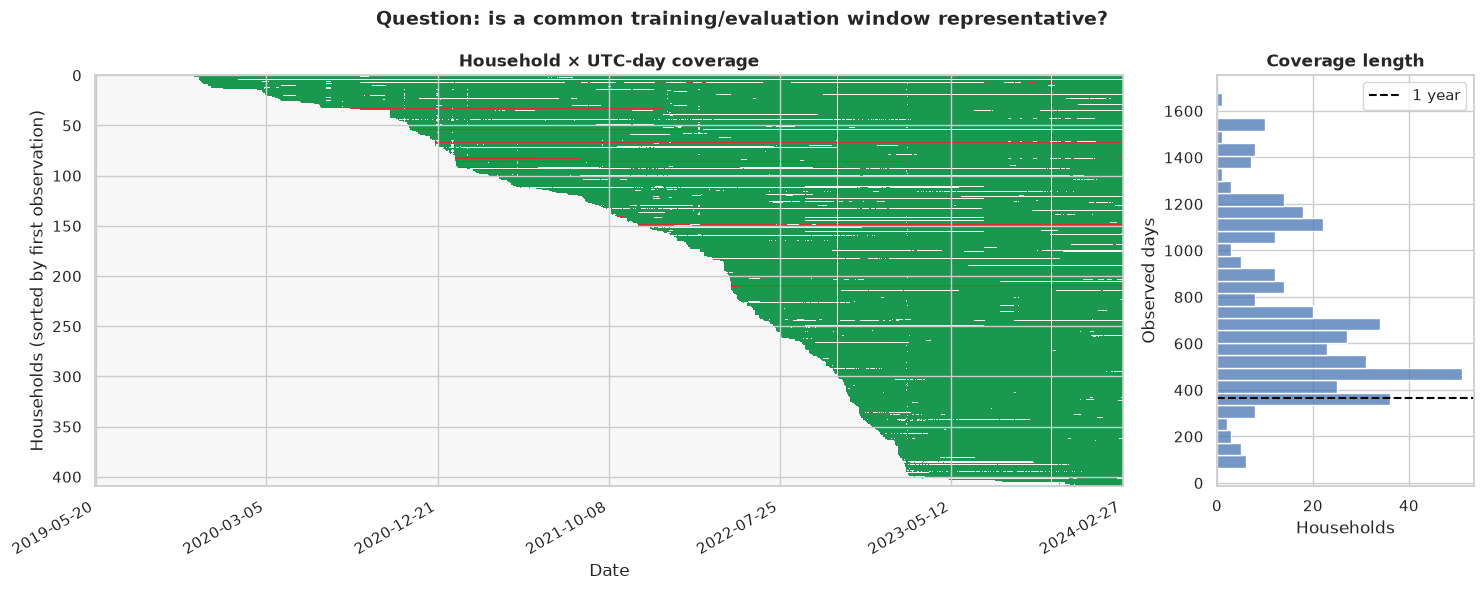

In [4]:
dq = daily_quality.select('Household_ID', 'date_utc', 'day_complete').to_pandas()
dq['state'] = np.where(dq['day_complete'], 2, 1)
all_dates = pd.date_range(dq['date_utc'].min(), dq['date_utc'].max(), freq='D').date
coverage_order = (daily_quality.group_by('Household_ID').agg(pl.col('date_utc').min().alias('first'))
                  .sort('first')['Household_ID'].to_list())
coverage = (dq.pivot(index='Household_ID', columns='date_utc', values='state')
            .reindex(index=coverage_order, columns=all_dates).fillna(0))
coverage_days = metadata['SMD_15min_TimeAvailable_NumberDays'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [4, 1]})
axes[0].imshow(coverage.to_numpy(), aspect='auto', interpolation='nearest',
               cmap=ListedColormap(['#f7f7f7', '#d73027', '#1a9850']), vmin=0, vmax=2)
tick_idx = np.linspace(0, len(all_dates)-1, 7, dtype=int)
axes[0].set_xticks(tick_idx, [str(all_dates[i]) for i in tick_idx], rotation=30, ha='right')
axes[0].set(title='Household × UTC-day coverage', xlabel='Date', ylabel='Households (sorted by first observation)')
sns.histplot(y=coverage_days, bins=30, ax=axes[1], color='#4575b4')
axes[1].axhline(365, color='black', linestyle='--', label='1 year')
axes[1].set(title='Coverage length', xlabel='Households', ylabel='Observed days')
axes[1].legend()
fig.suptitle('Question: is a common training/evaluation window representative?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Figure 2 — Is missingness isolated, prolonged, or systematic?

All observed UTC days contain 96 timestamp rows; incomplete days arise from null target values. Timestamp gaps therefore represent omitted whole-day blocks rather than sporadic missing quarter-hours.

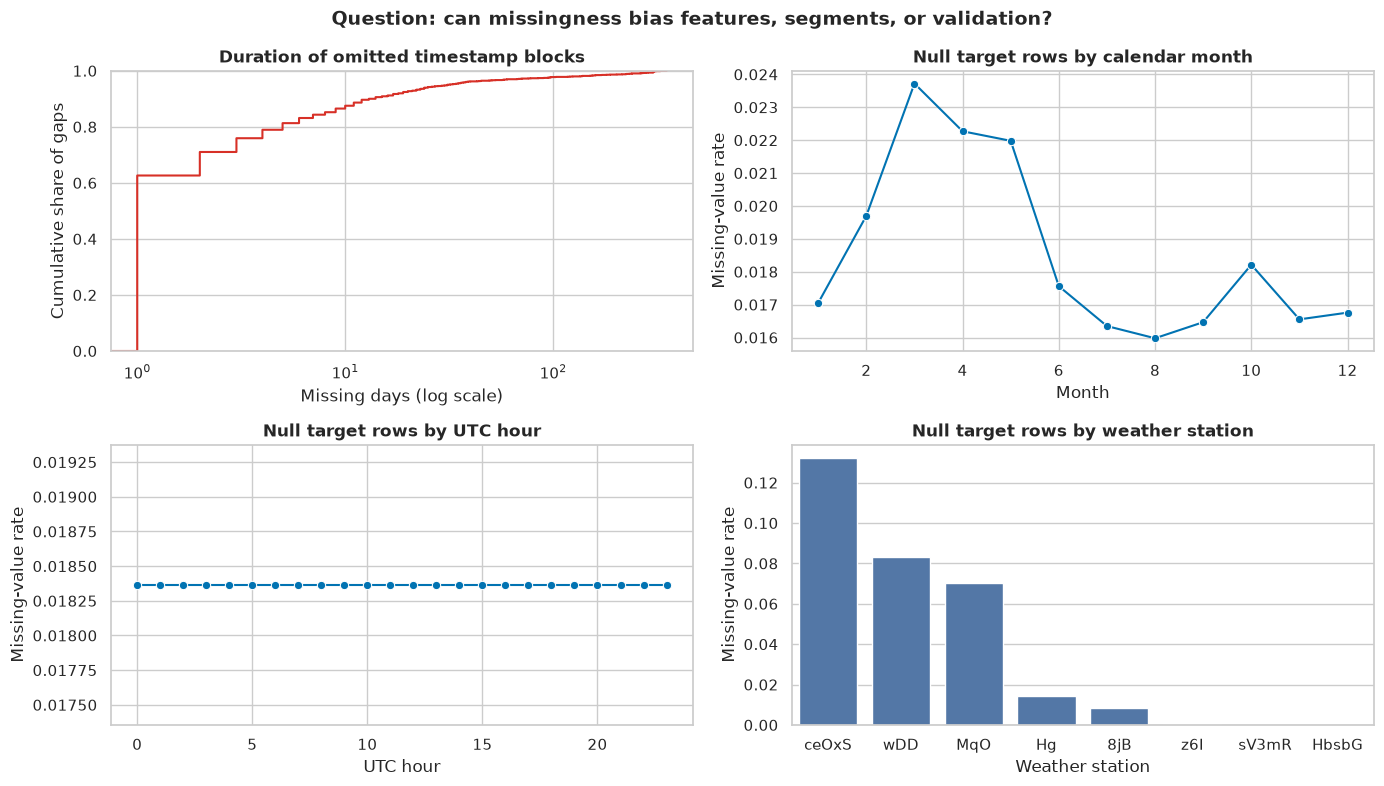

,AffectsTimePoint,target missing rate by intervention state
0,during visit,0.042017
1,before visit,0.032710
2,after visit,0.024440
3,unknown,0.009471


,Gap statistic,Missing days
0,median,1.0
1,90th percentile,13.0
2,maximum,351.0
3,gaps ≥ 1 week,285.0


In [5]:
quality_with_meta = meter.join(
    metadata.select('Household_ID', 'Weather_ID').lazy(), on='Household_ID', how='left'
).with_columns(
    pl.col('timestamp_utc').dt.month().alias('month'),
    pl.col('timestamp_utc').dt.hour().alias('utc_hour'),
)
missing_month = quality_with_meta.group_by('month').agg(
    pl.col('kWh_received_Total').is_null().mean().alias('missing_rate')).sort('month').collect().to_pandas()
missing_hour = quality_with_meta.group_by('utc_hour').agg(
    pl.col('kWh_received_Total').is_null().mean().alias('missing_rate')).sort('utc_hour').collect().to_pandas()
missing_station = quality_with_meta.group_by('Weather_ID').agg(
    pl.col('kWh_received_Total').is_null().mean().alias('missing_rate')).sort('missing_rate', descending=True).collect().to_pandas()
missing_intervention = meter.group_by('AffectsTimePoint').agg(
    pl.col('kWh_received_Total').is_null().mean().alias('missing_rate')).sort('missing_rate', descending=True).collect().to_pandas()
gap_days = gaps['missing_intervals'].to_numpy() / 96

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.ecdfplot(x=gap_days, ax=axes[0,0], color='#d73027')
axes[0,0].set_xscale('log')
axes[0,0].set(title='Duration of omitted timestamp blocks', xlabel='Missing days (log scale)', ylabel='Cumulative share of gaps')
sns.lineplot(data=missing_month, x='month', y='missing_rate', marker='o', ax=axes[0,1])
axes[0,1].set(title='Null target rows by calendar month', xlabel='Month', ylabel='Missing-value rate')
sns.lineplot(data=missing_hour, x='utc_hour', y='missing_rate', marker='o', ax=axes[1,0])
axes[1,0].set(title='Null target rows by UTC hour', xlabel='UTC hour', ylabel='Missing-value rate')
sns.barplot(data=missing_station, x='Weather_ID', y='missing_rate', ax=axes[1,1], color='#4575b4')
axes[1,1].set(title='Null target rows by weather station', xlabel='Weather station', ylabel='Missing-value rate')
fig.suptitle('Question: can missingness bias features, segments, or validation?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(missing_intervention.rename(columns={'missing_rate': 'target missing rate by intervention state'}))
display(pd.DataFrame({'Gap statistic': ['median', '90th percentile', 'maximum', 'gaps ≥ 1 week'],
                      'Missing days': [np.median(gap_days), np.quantile(gap_days, .9), gap_days.max(), (gap_days >= 7).sum()]}))

## 3. Target and component semantics

Only 21 households expose heat-pump readings and 17 expose other-load readings. Where all three quantities exist, verify whether `total = heat pump + other` before treating decomposition as a modelling identity. Extremely large values are flagged relative to empirical quantiles, not declared physically impossible without meter-domain confirmation.

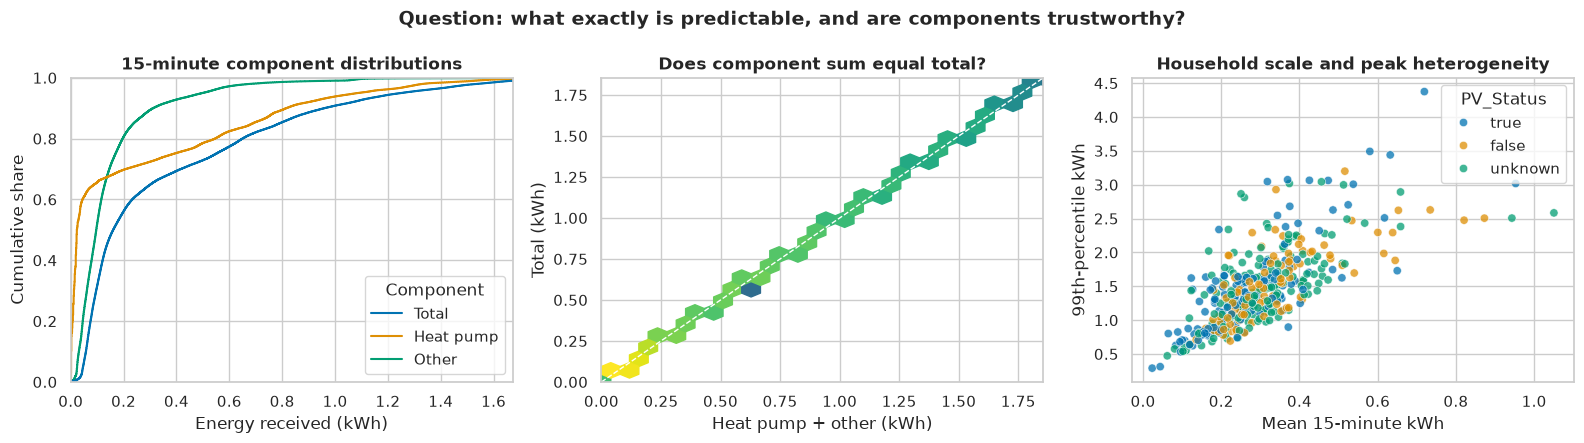

,rows,households,mean_absolute_residual,maximum_absolute_residual,exact_within_1e-6_share
0,1120416,17,1.636372e-17,4.440892e-16,1.0


,Household_ID,timestamp_utc,kWh_received_Total
0,676510,2021-01-09 23:00:00+00:00,66.976
1,7569701,2024-01-19 21:15:00+00:00,27.304
2,116977,2021-01-08 23:00:00+00:00,9.914
3,712718,2021-09-26 23:00:00+00:00,9.834
4,109104,2021-09-27 02:30:00+00:00,9.573
5,1111201,2022-12-12 19:00:00+00:00,8.620
6,1111201,2024-01-15 19:15:00+00:00,8.615
7,1111201,2024-01-15 19:00:00+00:00,8.248
8,1111201,2022-12-12 18:45:00+00:00,8.204
9,1111201,2024-01-15 19:30:00+00:00,7.727


In [6]:
component_rows = meter.filter(
    pl.any_horizontal(pl.col('kWh_received_HeatPump', 'kWh_received_Other').is_not_null())
).select('Household_ID', 'kWh_received_Total', 'kWh_received_HeatPump', 'kWh_received_Other').collect()
complete_components = component_rows.drop_nulls(['kWh_received_Total', 'kWh_received_HeatPump', 'kWh_received_Other']).with_columns(
    (pl.col('kWh_received_Total') - pl.col('kWh_received_HeatPump') - pl.col('kWh_received_Other')).alias('decomposition_residual')
)
decomposition = complete_components.select(
    pl.len().alias('rows'), pl.col('Household_ID').n_unique().alias('households'),
    pl.col('decomposition_residual').abs().mean().alias('mean_absolute_residual'),
    pl.col('decomposition_residual').abs().max().alias('maximum_absolute_residual'),
    (pl.col('decomposition_residual').abs() <= 1e-6).mean().alias('exact_within_1e-6_share'),
)
household_target = meter.group_by('Household_ID').agg(
    pl.col('kWh_received_Total').mean().alias('mean_kwh'),
    pl.col('kWh_received_Total').quantile(.99).alias('p99_kwh'),
    pl.col('kWh_received_Total').max().alias('max_kwh'),
).collect().join(metadata.select('Household_ID', 'PV_Status'), on='Household_ID', how='left')
top_values = meter.drop_nulls('kWh_received_Total').sort('kWh_received_Total', descending=True).select(
    'Household_ID', 'timestamp_utc', 'kWh_received_Total').head(10).collect()

samples = []
for col, label in [('kWh_received_Total','Total'), ('kWh_received_HeatPump','Heat pump'), ('kWh_received_Other','Other')]:
    available = component_rows.select(col).drop_nulls()
    samples.append(available.sample(n=min(150_000, available.height), seed=42).rename({col: 'kWh'}).with_columns(pl.lit(label).alias('Component')))
component_sample = pl.concat(samples).to_pandas()
decomp_sample = complete_components.sample(n=min(80_000, complete_components.height), seed=42).to_pandas()
hh_target_pd = household_target.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.ecdfplot(data=component_sample, x='kWh', hue='Component', ax=axes[0])
axes[0].set_xlim(0, component_sample['kWh'].quantile(.995))
axes[0].set(title='15-minute component distributions', xlabel='Energy received (kWh)', ylabel='Cumulative share')
axes[1].hexbin(decomp_sample['kWh_received_HeatPump'] + decomp_sample['kWh_received_Other'],
                 decomp_sample['kWh_received_Total'], gridsize=45, bins='log', cmap='viridis')
limit = decomp_sample['kWh_received_Total'].quantile(.995)
axes[1].plot([0, limit], [0, limit], '--', color='white', linewidth=1)
axes[1].set(xlim=(0,limit), ylim=(0,limit), title='Does component sum equal total?', xlabel='Heat pump + other (kWh)', ylabel='Total (kWh)')
sns.scatterplot(data=hh_target_pd, x='mean_kwh', y='p99_kwh', hue='PV_Status', alpha=.75, ax=axes[2])
axes[2].set(title='Household scale and peak heterogeneity', xlabel='Mean 15-minute kWh', ylabel='99th-percentile kWh')
fig.suptitle('Question: what exactly is predictable, and are components trustworthy?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(decomposition.to_pandas())
display(top_values.to_pandas())

## 4. Analysis cohort

For like-for-like profile and baseline comparisons, use households with at least 95% complete hourly observations in the final 180 days. This reduces changing-composition artifacts but is a retrospective evaluation filter and may favor reliable meters. It must not be used as a future-known feature.

In [7]:
hourly_panel = build_hourly_panel(meter=meter, metadata=metadata, weather=weather)
stable_hourly, cohort = stable_cohort(hourly_panel, window_days=180, minimum_completeness=.95)
stable_ids = cohort.filter('is_stable')['Household_ID']
analysis_start = stable_hourly['timestamp_utc'].min()
analysis_end = stable_hourly['timestamp_utc'].max()

paired_ids = (hourly_panel.filter((pl.col('Group') == 'treatment') & pl.col('AffectsTimePoint').is_in(['before visit','after visit']))
              .group_by('Household_ID').agg(pl.col('AffectsTimePoint').n_unique().alias('states'))
              .filter(pl.col('states') == 2)['Household_ID'])
intervention_base = hourly_panel.filter(
    pl.col('Household_ID').is_in(paired_ids.to_list()) & pl.col('AffectsTimePoint').is_in(['before visit','after visit'])
)
intervention_profile = (intervention_base.group_by('Household_ID','AffectsTimePoint','local_hour')
    .agg(pl.col('hourly_kwh').mean().alias('household_mean'))
    .group_by('AffectsTimePoint','local_hour').agg(pl.col('household_mean').mean().alias('mean_kwh')).sort('local_hour'))
intervention_temp = (intervention_base.filter(pl.col('Temperature_avg_hourly').is_not_null())
    .with_columns(((pl.col('Temperature_avg_hourly')/2).floor()*2).alias('temperature_bin'))
    .group_by('Household_ID','AffectsTimePoint','temperature_bin').agg(
        pl.col('hourly_kwh').mean().alias('total_kwh'),
        pl.col('hourly_heatpump_kwh').mean().alias('heatpump_kwh'))
    .group_by('AffectsTimePoint','temperature_bin').agg(
        pl.col('total_kwh').mean(), pl.col('heatpump_kwh').mean(),
        pl.col('total_kwh').count().alias('households'))
    .filter(pl.col('households') >= 5).sort('temperature_bin'))

del stable_hourly, intervention_base
gc.collect()
intervals = build_interval_panel(meter, metadata, weather, stable_ids, analysis_start, analysis_end)
display(pd.DataFrame({'cohort households': [len(stable_ids)], 'start': [analysis_start], 'end': [analysis_end],
                      'paired intervention households': [len(paired_ids)]}))

,cohort households,start,end,paired intervention households
0,354,2023-09-01 00:00:00+00:00,2024-02-27 23:00:00+00:00,127


## 5. Temporal structure

### Figure 4 — What recurring within-day patterns can a model exploit?

Profiles first average each household within a category, then summarize across households. This prevents households with slightly better coverage from dominating the curves. The band represents household heterogeneity, not a confidence interval.

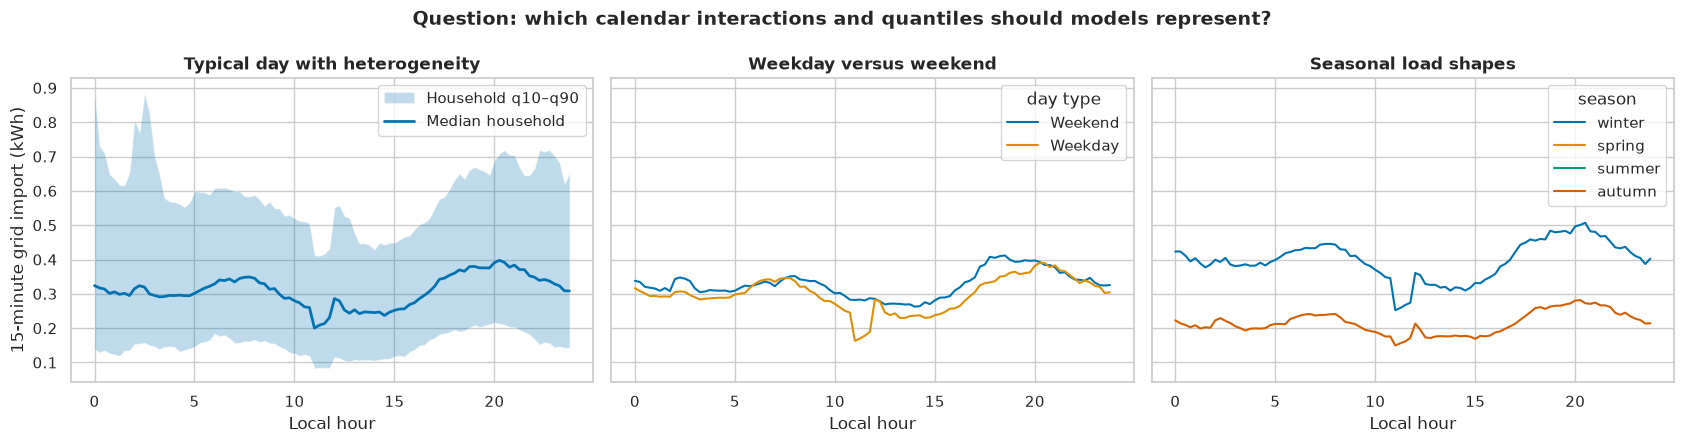

In [8]:
valid_intervals = intervals.filter(pl.col('kWh_received_Total').is_not_null())
overall_hh_profile = valid_intervals.group_by('Household_ID','local_slot').agg(
    pl.col('kWh_received_Total').mean().alias('mean_kwh'))
overall_profile = overall_hh_profile.group_by('local_slot').agg(
    pl.col('mean_kwh').quantile(.1).alias('q10'), pl.col('mean_kwh').median().alias('median'),
    pl.col('mean_kwh').quantile(.9).alias('q90')).sort('local_slot').to_pandas()
week_profile = (valid_intervals.group_by('Household_ID','is_weekend','local_slot').agg(pl.col('kWh_received_Total').mean().alias('hh_mean'))
                .group_by('is_weekend','local_slot').agg(pl.col('hh_mean').median().alias('median')).sort('local_slot').to_pandas())
season_profile = (valid_intervals.group_by('Household_ID','season','local_slot').agg(pl.col('kWh_received_Total').mean().alias('hh_mean'))
                  .group_by('season','local_slot').agg(pl.col('hh_mean').median().alias('median')).sort('local_slot').to_pandas())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
x = overall_profile['local_slot']/4
axes[0].fill_between(x, overall_profile['q10'], overall_profile['q90'], alpha=.25, label='Household q10–q90')
axes[0].plot(x, overall_profile['median'], linewidth=2, label='Median household')
axes[0].set(title='Typical day with heterogeneity', xlabel='Local hour', ylabel='15-minute grid import (kWh)')
axes[0].legend()
week_profile['day type'] = week_profile['is_weekend'].map({False:'Weekday', True:'Weekend'})
sns.lineplot(data=week_profile, x=week_profile['local_slot']/4, y='median', hue='day type', ax=axes[1])
axes[1].set(title='Weekday versus weekend', xlabel='Local hour', ylabel='')
sns.lineplot(data=season_profile, x=season_profile['local_slot']/4, y='median', hue='season', hue_order=SEASON_ORDER, ax=axes[2])
axes[2].set(title='Seasonal load shapes', xlabel='Local hour', ylabel='')
fig.suptitle('Question: which calendar interactions and quantiles should models represent?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Figure 5 — Which hour × calendar interactions matter?

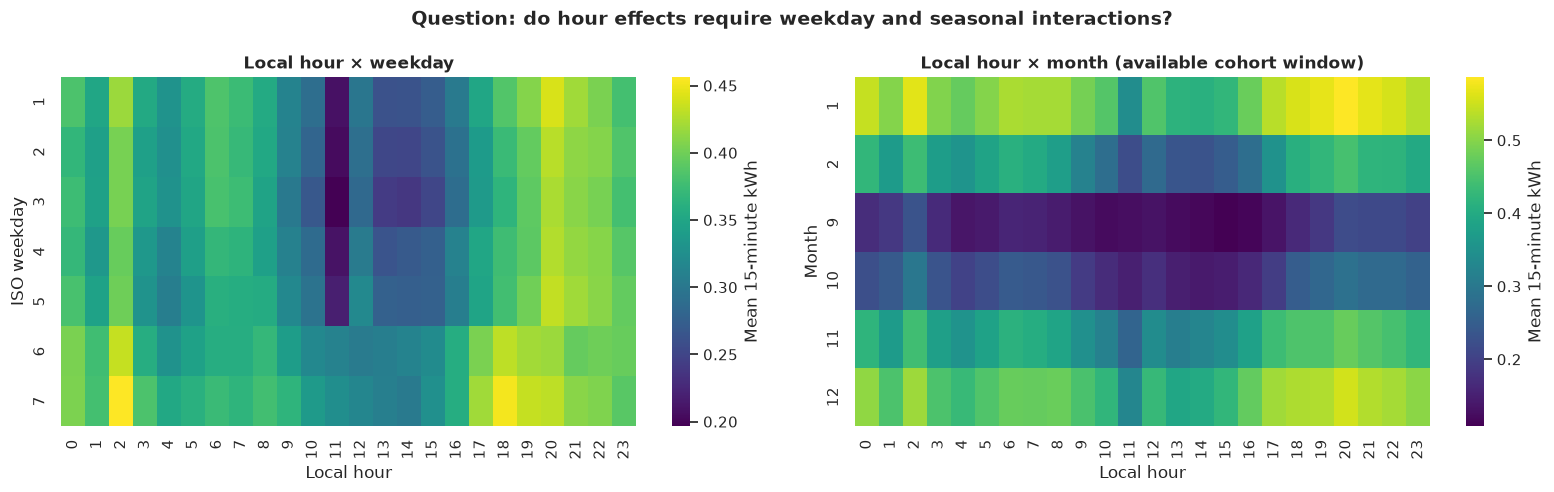

In [9]:
weekday_hour = valid_intervals.group_by('local_weekday','local_hour').agg(pl.col('kWh_received_Total').mean().alias('mean_kwh')).to_pandas()
month_hour = valid_intervals.group_by('local_month','local_hour').agg(pl.col('kWh_received_Total').mean().alias('mean_kwh')).to_pandas()
wh = weekday_hour.pivot(index='local_weekday', columns='local_hour', values='mean_kwh').sort_index()
mh = month_hour.pivot(index='local_month', columns='local_hour', values='mean_kwh').sort_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(wh, cmap='viridis', ax=axes[0], cbar_kws={'label':'Mean 15-minute kWh'})
axes[0].set(title='Local hour × weekday', xlabel='Local hour', ylabel='ISO weekday')
sns.heatmap(mh, cmap='viridis', ax=axes[1], cbar_kws={'label':'Mean 15-minute kWh'})
axes[1].set(title='Local hour × month (available cohort window)', xlabel='Local hour', ylabel='Month')
fig.suptitle('Question: do hour effects require weekday and seasonal interactions?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Lag structure and direct forecastability

### Figure 6 — Which exact historical offsets justify features and persistence baselines?

Lags are joined by timestamp, never by row position, so omitted days cannot make an older value masquerade as the previous interval.

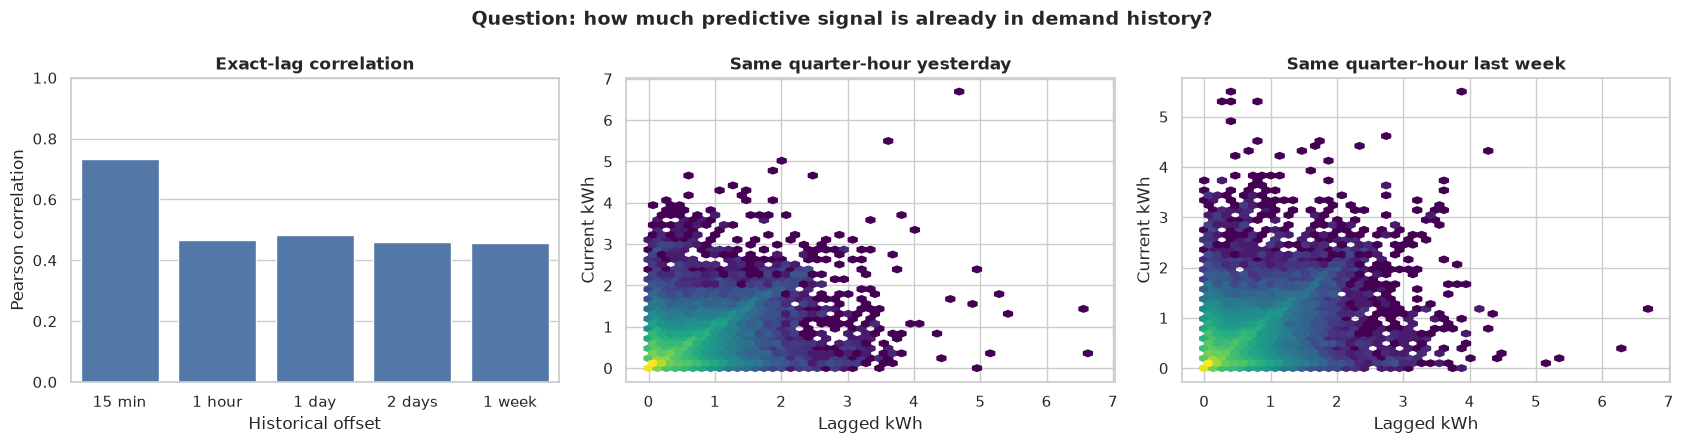

,lag,steps,pairs,correlation,persistence_MAE_kWh
0,15 min,1,6075896,0.7320,0.1620
1,1 hour,4,6073733,0.4679,0.2488
2,1 day,96,6007401,0.4828,0.2389
3,2 days,192,5972841,0.4593,0.2488
4,1 week,672,5801961,0.4578,0.2535


In [10]:
lagged = add_exact_lags(intervals.select('Household_ID','timestamp_utc','kWh_received_Total'))
lag_rows = []
for lag, label in [(1,'15 min'),(4,'1 hour'),(96,'1 day'),(192,'2 days'),(672,'1 week')]:
    valid = lagged.drop_nulls(['kWh_received_Total', f'lag_{lag}'])
    lag_rows.append({
        'lag': label, 'steps': lag, 'pairs': valid.height,
        'correlation': valid.select(pl.corr('kWh_received_Total', f'lag_{lag}')).item(),
        'persistence_MAE_kWh': valid.select((pl.col('kWh_received_Total')-pl.col(f'lag_{lag}')).abs().mean()).item(),
    })
lag_stats = pd.DataFrame(lag_rows)
day_sample = lagged.drop_nulls(['kWh_received_Total','lag_96']).sample(n=80_000, seed=42).to_pandas()
week_sample = lagged.drop_nulls(['kWh_received_Total','lag_672']).sample(n=80_000, seed=42).to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.barplot(data=lag_stats, x='lag', y='correlation', ax=axes[0], color='#4575b4')
axes[0].set(title='Exact-lag correlation', xlabel='Historical offset', ylabel='Pearson correlation', ylim=(0,1))
axes[1].hexbin(day_sample['lag_96'], day_sample['kWh_received_Total'], gridsize=50, bins='log', cmap='viridis')
axes[1].set(title='Same quarter-hour yesterday', xlabel='Lagged kWh', ylabel='Current kWh')
axes[2].hexbin(week_sample['lag_672'], week_sample['kWh_received_Total'], gridsize=50, bins='log', cmap='viridis')
axes[2].set(title='Same quarter-hour last week', xlabel='Lagged kWh', ylabel='Current kWh')
fig.suptitle('Question: how much predictive signal is already in demand history?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(lag_stats.round(4))
del lagged, day_sample, week_sample
_ = gc.collect()

## 7. Household heterogeneity

### Figure 7 — Are households merely different in scale, or also in load shape and weather response?

PCA uses each household's normalized 96-slot profile. K-means is retained only as a diagnostic: low silhouette scores imply a continuum rather than defensible hard archetypes.

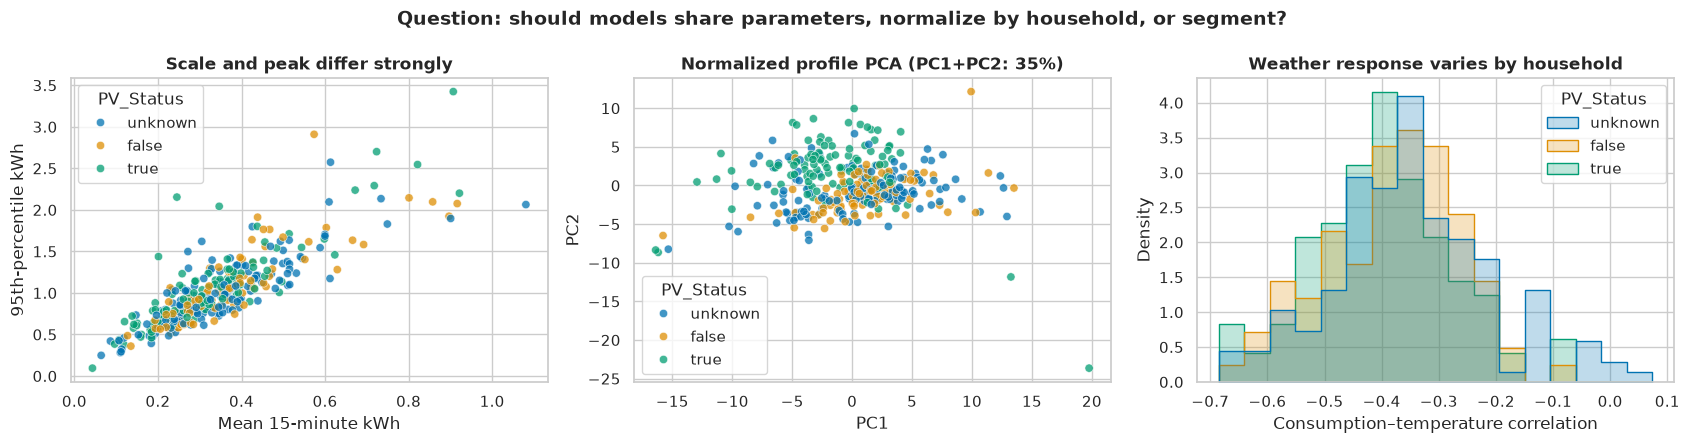

,clusters,silhouette
0,2,0.259
1,3,0.254
2,4,0.257
3,5,0.165
4,6,0.220


In [11]:
household_features = valid_intervals.group_by('Household_ID').agg(
    pl.col('kWh_received_Total').mean().alias('mean_kwh'),
    pl.col('kWh_received_Total').quantile(.1).alias('baseload_p10_kwh'),
    pl.col('kWh_received_Total').quantile(.95).alias('peak_p95_kwh'),
    pl.col('kWh_received_Total').std().alias('variability_kwh'),
    pl.corr('kWh_received_Total','Temperature_avg_hourly').alias('temperature_correlation'),
    pl.col('kWh_received_Total').filter(pl.col('is_weekend')).mean().alias('weekend_mean_kwh'),
    pl.col('kWh_received_Total').filter(~pl.col('is_weekend')).mean().alias('weekday_mean_kwh'),
    pl.col('PV_Status').first().alias('PV_Status'),
).with_columns((pl.col('weekend_mean_kwh')-pl.col('weekday_mean_kwh')).alias('weekend_delta_kwh'))
profile_wide = overall_hh_profile.pivot(on='local_slot', index='Household_ID', values='mean_kwh').drop_nulls()
profile_ids = profile_wide['Household_ID']
X = profile_wide.drop('Household_ID').to_numpy()
X = X / X.mean(axis=1, keepdims=True)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=5, random_state=42)
Z = pca.fit_transform(X_scaled)
silhouettes = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(Z)
    silhouettes.append({'clusters': k, 'silhouette': silhouette_score(Z, labels)})
pca_frame = pl.DataFrame({'Household_ID': profile_ids, 'PC1': Z[:,0], 'PC2': Z[:,1]}).join(
    metadata.select('Household_ID','PV_Status'), on='Household_ID', how='left').to_pandas()
features_pd = household_features.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=features_pd, x='mean_kwh', y='peak_p95_kwh', hue='PV_Status', alpha=.75, ax=axes[0])
axes[0].set(title='Scale and peak differ strongly', xlabel='Mean 15-minute kWh', ylabel='95th-percentile kWh')
sns.scatterplot(data=pca_frame, x='PC1', y='PC2', hue='PV_Status', alpha=.75, ax=axes[1])
axes[1].set(title=f'Normalized profile PCA (PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.0%})', xlabel='PC1', ylabel='PC2')
sns.histplot(data=features_pd, x='temperature_correlation', hue='PV_Status', element='step', stat='density', common_norm=False, ax=axes[2])
axes[2].set(title='Weather response varies by household', xlabel='Consumption–temperature correlation', ylabel='Density')
fig.suptitle('Question: should models share parameters, normalize by household, or segment?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(pd.DataFrame(silhouettes).round(3))

## 8. Weather sensitivity

### Figure 8 — Is temperature useful, nonlinear, component-specific, and heterogeneous?

Realised weather is used only to diagnose signal. A production backtest must substitute the weather forecast that would have existed at each forecast origin.

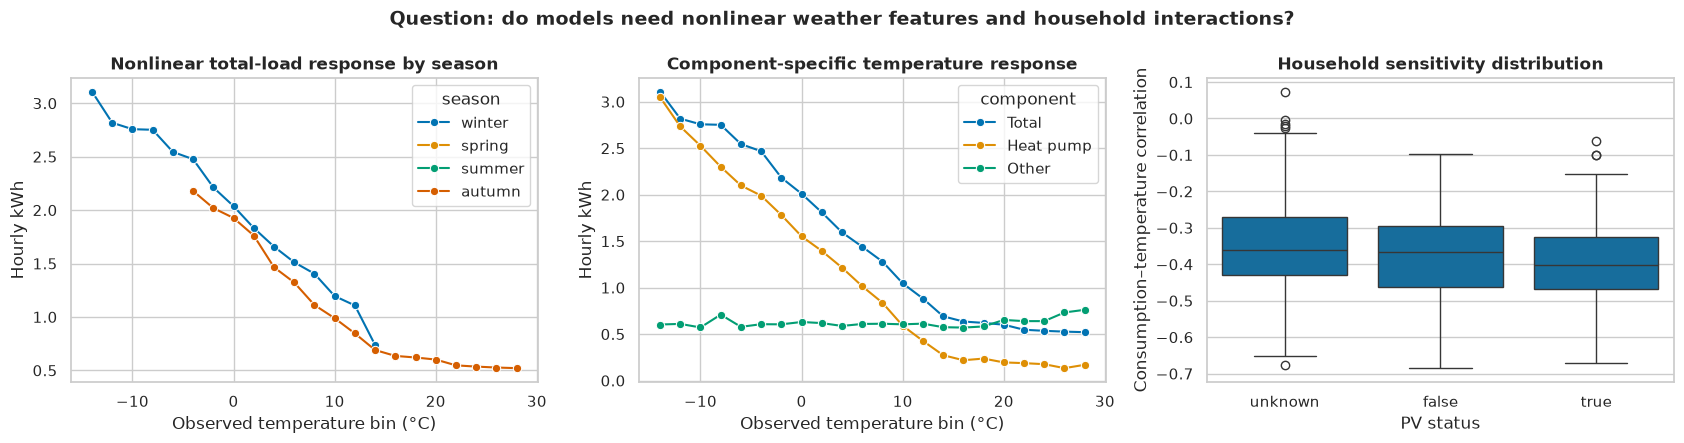

In [12]:
hourly_weather = (intervals.with_columns(pl.col('timestamp_utc').dt.truncate('1h').alias('hour_utc'))
    .group_by('Household_ID','hour_utc','season','Temperature_avg_hourly').agg(
        pl.col('kWh_received_Total').count().alias('n_total'),
        pl.col('kWh_received_HeatPump').count().alias('n_hp'),
        pl.col('kWh_received_Other').count().alias('n_other'),
        pl.col('kWh_received_Total').sum().alias('total_sum'),
        pl.col('kWh_received_HeatPump').sum().alias('hp_sum'),
        pl.col('kWh_received_Other').sum().alias('other_sum'))
    .with_columns(
        pl.when(pl.col('n_total')==4).then(pl.col('total_sum')).alias('total_kwh'),
        pl.when(pl.col('n_hp')==4).then(pl.col('hp_sum')).alias('heatpump_kwh'),
        pl.when(pl.col('n_other')==4).then(pl.col('other_sum')).alias('other_kwh'),
        ((pl.col('Temperature_avg_hourly')/2).floor()*2).alias('temperature_bin'),
        (pl.lit(15)-pl.col('Temperature_avg_hourly')).clip(lower_bound=0).alias('heating_degree_15c'))
)
temp_total = (hourly_weather.group_by('Household_ID','season','temperature_bin').agg(pl.col('total_kwh').mean().alias('hh_mean'))
              .group_by('season','temperature_bin').agg(pl.col('hh_mean').mean().alias('mean_kwh'),pl.col('hh_mean').count().alias('households'))
              .filter(pl.col('households')>=30).sort('temperature_bin').to_pandas())
component_curves = []
for col,label in [('total_kwh','Total'),('heatpump_kwh','Heat pump'),('other_kwh','Other')]:
    curve=(hourly_weather.group_by('Household_ID','temperature_bin').agg(pl.col(col).mean().alias('hh_mean'))
           .group_by('temperature_bin').agg(pl.col('hh_mean').mean().alias('mean_kwh'),pl.col('hh_mean').count().alias('households'))
           .filter(pl.col('households') >= (30 if col=='total_kwh' else 5)).with_columns(pl.lit(label).alias('component')))
    component_curves.append(curve)
component_curves = pl.concat(component_curves).sort('temperature_bin').to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.lineplot(data=temp_total, x='temperature_bin', y='mean_kwh', hue='season', hue_order=SEASON_ORDER, marker='o', ax=axes[0])
axes[0].set(title='Nonlinear total-load response by season', xlabel='Observed temperature bin (°C)', ylabel='Hourly kWh')
sns.lineplot(data=component_curves, x='temperature_bin', y='mean_kwh', hue='component', marker='o', ax=axes[1])
axes[1].set(title='Component-specific temperature response', xlabel='Observed temperature bin (°C)', ylabel='Hourly kWh')
sns.boxplot(data=features_pd, y='temperature_correlation', x='PV_Status', ax=axes[2])
axes[2].set(title='Household sensitivity distribution', xlabel='PV status', ylabel='Consumption–temperature correlation')
fig.suptitle('Question: do models need nonlinear weather features and household interactions?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. PV ownership

### Figure 9 — Does a reported PV system leave a repeatable signature in grid import?

PV status is missing for 165 households. Curves compare known `true` and `false` labels only and should not be interpreted as measured PV generation.

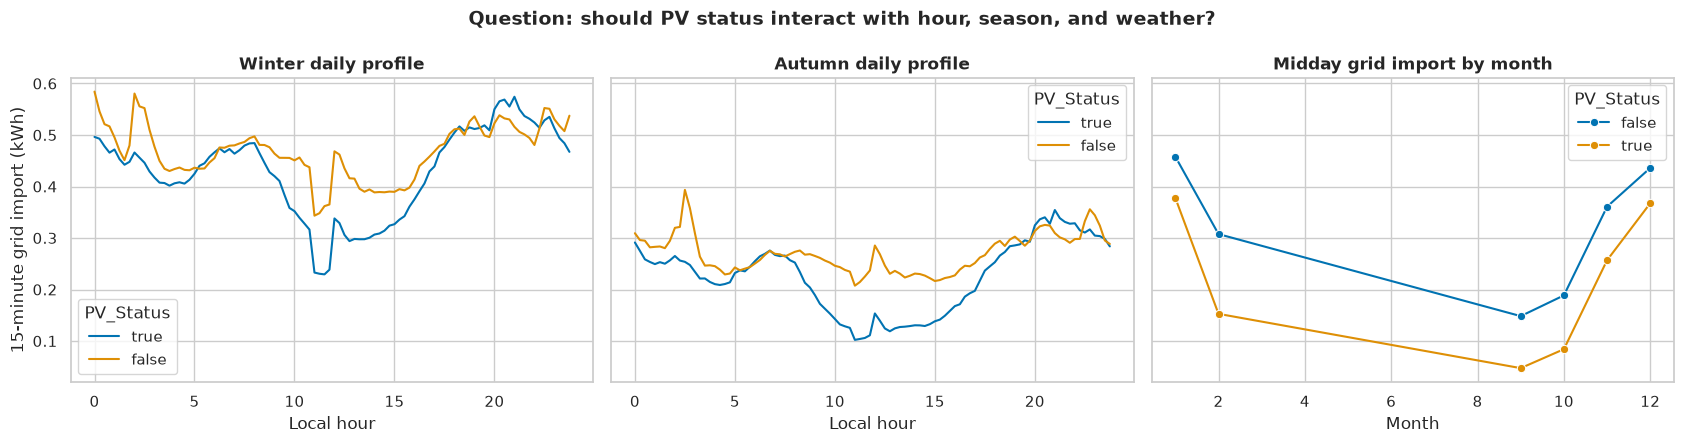

,PV_Status,len
0,false,114
1,true,131
2,unknown,165


In [13]:
pv_profiles = (valid_intervals.filter(pl.col('PV_Status').is_in(['true','false']))
    .group_by('Household_ID','PV_Status','season','local_slot').agg(pl.col('kWh_received_Total').mean().alias('hh_mean'))
    .group_by('PV_Status','season','local_slot').agg(pl.col('hh_mean').mean().alias('mean_kwh')).sort('local_slot').to_pandas())
pv_midday = (valid_intervals.filter(pl.col('PV_Status').is_in(['true','false']) & pl.col('local_hour').is_between(10,15))
    .group_by('Household_ID','PV_Status','local_month').agg(pl.col('kWh_received_Total').mean().alias('hh_mean'))
    .group_by('PV_Status','local_month').agg(pl.col('hh_mean').mean().alias('mean_kwh')).sort('local_month').to_pandas())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, season in zip(axes[:2], ['winter','autumn']):
    subset=pv_profiles[pv_profiles['season']==season]
    sns.lineplot(data=subset, x=subset['local_slot']/4, y='mean_kwh', hue='PV_Status', ax=ax)
    ax.set(title=f'{season.title()} daily profile', xlabel='Local hour', ylabel='15-minute grid import (kWh)')
sns.lineplot(data=pv_midday, x='local_month', y='mean_kwh', hue='PV_Status', marker='o', ax=axes[2])
axes[2].set(title='Midday grid import by month', xlabel='Month', ylabel='15-minute grid import (kWh)')
fig.suptitle('Question: should PV status interact with hour, season, and weather?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(metadata.group_by('PV_Status').len().sort('PV_Status').to_pandas())

## 10. Intervention / heat-pump optimization

### Figure 10 — Does the intervention create a forecast-relevant distribution shift?

Only treatment households observed both before and after the visit are retained, and each household receives equal weight. Temperature-bin comparisons reduce weather confounding, but this remains descriptive: season, equipment aging, occupancy, and secular trends are not controlled. Component evidence is particularly small.

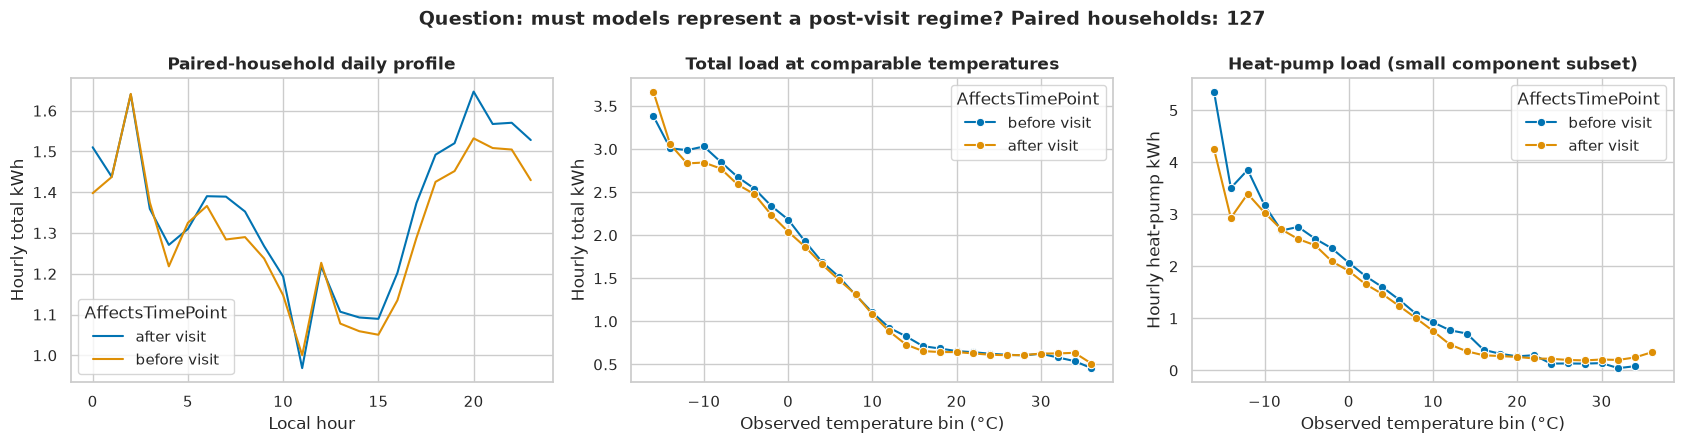

In [14]:
ip = intervention_profile.to_pandas()
it = intervention_temp.to_pandas()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.lineplot(data=ip, x='local_hour', y='mean_kwh', hue='AffectsTimePoint', ax=axes[0])
axes[0].set(title='Paired-household daily profile', xlabel='Local hour', ylabel='Hourly total kWh')
sns.lineplot(data=it, x='temperature_bin', y='total_kwh', hue='AffectsTimePoint', marker='o', ax=axes[1])
axes[1].set(title='Total load at comparable temperatures', xlabel='Observed temperature bin (°C)', ylabel='Hourly total kWh')
hp_it = it.dropna(subset=['heatpump_kwh'])
sns.lineplot(data=hp_it, x='temperature_bin', y='heatpump_kwh', hue='AffectsTimePoint', marker='o', ax=axes[2])
axes[2].set(title='Heat-pump load (small component subset)', xlabel='Observed temperature bin (°C)', ylabel='Hourly heat-pump kWh')
fig.suptitle(f'Question: must models represent a post-visit regime? Paired households: {len(paired_ids)}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Strict temporal baselines and error anatomy

The last 90 days of the common cohort window form the test period; the preceding 90 days supply the fixed historical time-of-day mean. Previous-day and previous-week forecasts use exact timestamp lags under the day-ahead contract: "previous day" takes the D-1 slot only where it was observed before the 10:00 UTC D-1 cutoff and the D-2 slot otherwise. Metrics report prediction coverage because missing lags must not be silently imputed.

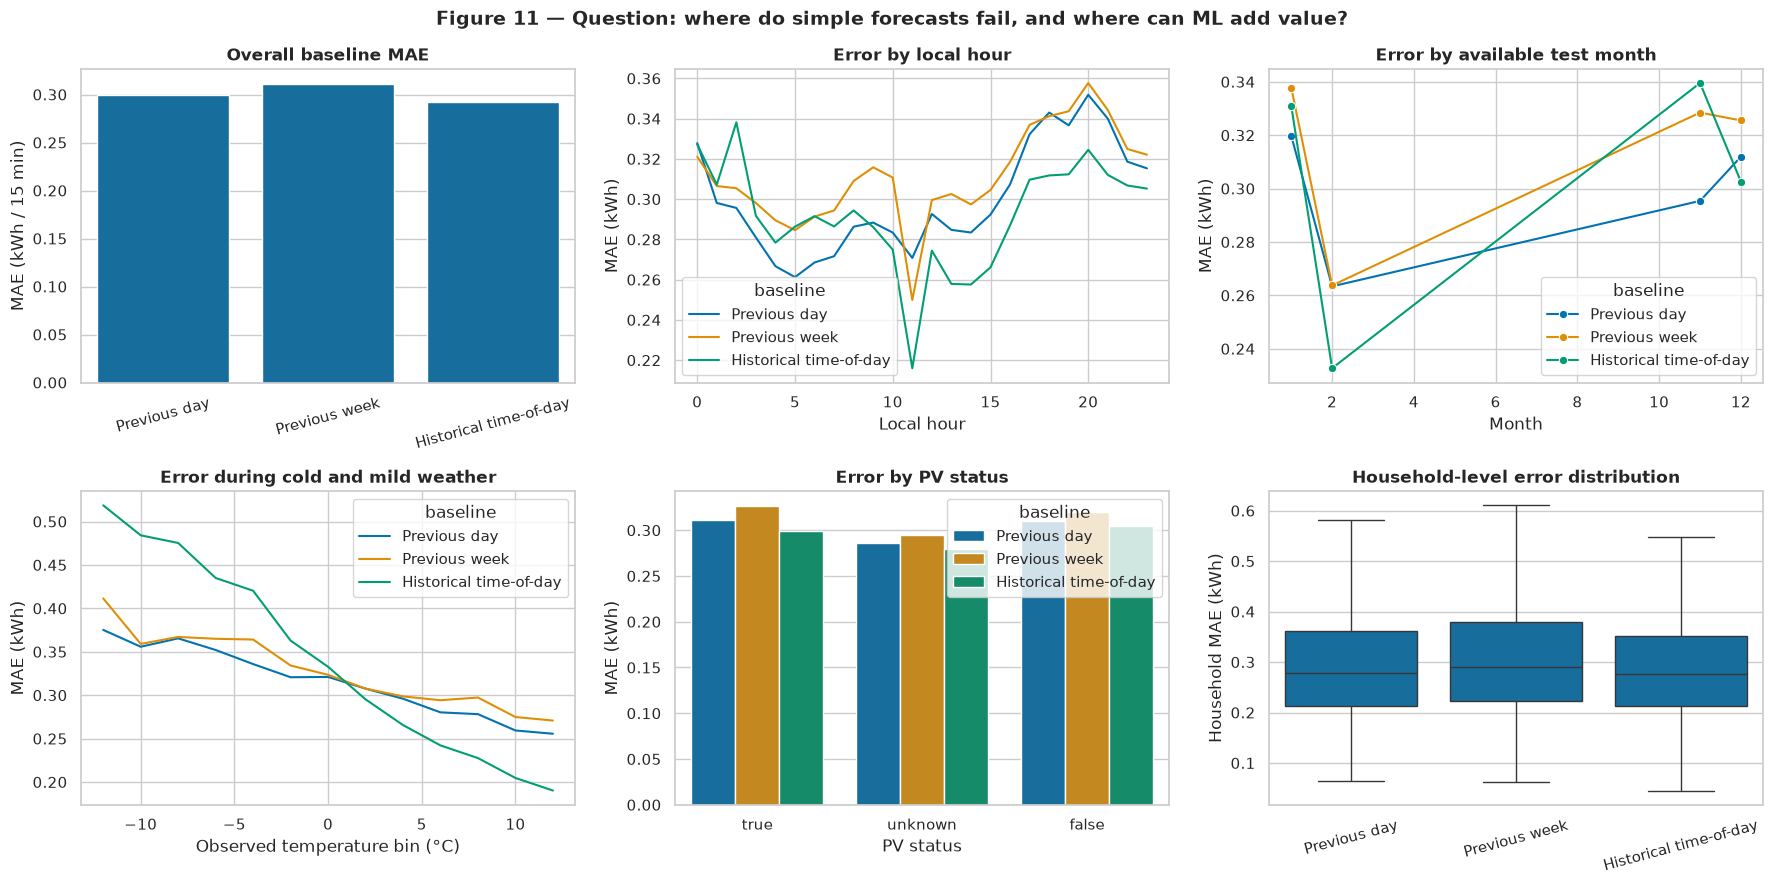

,MAE_kWh,RMSE_kWh,WAPE_pct,bias_actual_minus_forecast_kWh,evaluated_rows,baseline,prediction_coverage
0,0.2999,0.4795,67.2791,-0.0032,3053641,Previous day,0.9997
1,0.3112,0.4880,69.8288,-0.0095,3052809,Previous week,0.9995
2,0.2918,0.4427,65.4769,0.1955,3054441,Historical time-of-day,1.0000


**Additional error slices (MAE in kWh per 15 minutes):**

,is_weekend,MAE_kWh,RMSE_kWh,WAPE_pct,bias_actual_minus_forecast_kWh,evaluated_rows,baseline
0,False,0.2939,0.4715,67.7486,-0.0177,2171309,Previous day
1,True,0.3146,0.4987,66.2240,0.0325,882332,Previous day
2,False,0.3026,0.4770,69.7552,-0.0095,2170933,Previous week
3,True,0.3325,0.5140,69.9942,-0.0093,881876,Previous week
4,False,0.2819,0.4286,64.9978,0.1836,2171901,Historical time-of-day
5,True,0.3161,0.4758,66.5537,0.2248,882540,Historical time-of-day


,season,MAE_kWh,RMSE_kWh,WAPE_pct,bias_actual_minus_forecast_kWh,evaluated_rows,baseline
0,winter,0.2999,0.4797,67.4191,-0.0033,3021073,Previous day
1,autumn,0.2954,0.4588,56.2719,0.0075,32568,Previous day
2,autumn,0.3285,0.5121,62.5753,0.1020,32568,Previous week
3,winter,0.3110,0.4877,69.9211,-0.0107,3020241,Previous week
4,autumn,0.3395,0.4898,64.6831,0.2757,32568,Historical time-of-day
5,winter,0.2913,0.4422,65.4870,0.1946,3021873,Historical time-of-day


,AffectsTimePoint,MAE_kWh,RMSE_kWh,WAPE_pct,bias_actual_minus_forecast_kWh,evaluated_rows,baseline
0,before visit,0.2722,0.4041,53.0048,-0.0036,59805,Previous day
1,unknown,0.2915,0.4703,66.5022,-0.0031,2027347,Previous day
2,during visit,0.2599,0.3897,53.2860,-0.0309,1344,Previous day
3,after visit,0.3194,0.5024,69.8583,-0.0032,965145,Previous day
4,during visit,0.2621,0.4040,53.7409,-0.0117,1344,Previous week
5,after visit,0.3280,0.5081,71.7684,-0.0093,964641,Previous week
6,unknown,0.3038,0.4799,69.3047,-0.0096,2027019,Previous week
7,before visit,0.2953,0.4279,57.4928,-0.0049,59805,Previous week
8,after visit,0.3024,0.4576,66.1828,0.1990,965601,Historical time-of-day
9,unknown,0.2856,0.4349,65.1726,0.1914,2027691,Historical time-of-day


,Household_ID,MAE_kWh,RMSE_kWh,WAPE_pct,bias_actual_minus_forecast_kWh,evaluated_rows,baseline
0,1111201,0.8766,1.3979,75.7159,-0.0283,8637,Previous week
1,1111201,0.8152,1.3335,70.4095,-0.0070,8637,Previous day
2,851017,0.7912,1.0623,78.9252,-0.0258,8637,Previous week
3,1118211,0.7797,1.1189,89.4397,-0.0231,8637,Previous week
4,1118211,0.7757,1.1157,88.9859,-0.0078,8637,Previous day
5,121778,0.7643,1.0137,99.8512,-0.0215,8637,Previous week
6,122671,0.7520,0.9128,64.5598,0.6225,8637,Historical time-of-day
7,121778,0.7478,1.0005,97.7039,-0.0091,8637,Previous day
8,7771161,0.7400,0.9498,75.1584,-0.0281,8637,Previous week
9,851017,0.7329,1.0027,73.1042,-0.0054,8637,Previous day


In [15]:
predictions, test_start = temporal_baseline_predictions(intervals, test_days=90)
prediction_columns = list(BASELINE_LABELS)
target_rows = predictions['kWh_received_Total'].is_not_null().sum()

def grouped_errors(frame, groups):
    outputs=[]
    for prediction_col, model in BASELINE_LABELS.items():
        valid=frame.drop_nulls(['kWh_received_Total', prediction_col]).with_columns(
            (pl.col('kWh_received_Total')-pl.col(prediction_col)).alias('error'))
        summary=valid.group_by(groups).agg(
            pl.col('error').abs().mean().alias('MAE_kWh'),
            (pl.col('error').pow(2).mean().sqrt()).alias('RMSE_kWh'),
            (100*pl.col('error').abs().sum()/pl.col('kWh_received_Total').abs().sum()).alias('WAPE_pct'),
            pl.col('error').mean().alias('bias_actual_minus_forecast_kWh'),
            pl.len().alias('evaluated_rows'),
        ).with_columns(pl.lit(model).alias('baseline'))
        outputs.append(summary)
    return pl.concat(outputs)

overall_metrics = grouped_errors(predictions, []).with_columns(
    (pl.col('evaluated_rows')/target_rows).alias('prediction_coverage'))
predictions = predictions.with_columns(
    ((pl.col('Temperature_avg_hourly')/2).floor()*2).alias('temperature_bin'))
error_hour = grouped_errors(predictions, ['local_hour'])
error_month = grouped_errors(predictions, ['local_month'])
error_temp = grouped_errors(predictions, ['temperature_bin']).filter(pl.col('evaluated_rows') >= 5000)
error_pv = grouped_errors(predictions, ['PV_Status'])
error_household = grouped_errors(predictions, ['Household_ID'])
error_weekend = grouped_errors(predictions, ['is_weekend'])
error_intervention = grouped_errors(predictions, ['AffectsTimePoint'])
error_season = grouped_errors(predictions, ['season'])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
sns.barplot(data=overall_metrics.to_pandas(), x='baseline', y='MAE_kWh', ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].set(title='Overall baseline MAE', xlabel='', ylabel='MAE (kWh / 15 min)')
sns.lineplot(data=error_hour.to_pandas(), x='local_hour', y='MAE_kWh', hue='baseline', ax=axes[0,1])
axes[0,1].set(title='Error by local hour', xlabel='Local hour', ylabel='MAE (kWh)')
sns.lineplot(data=error_month.to_pandas(), x='local_month', y='MAE_kWh', hue='baseline', marker='o', ax=axes[0,2])
axes[0,2].set(title='Error by available test month', xlabel='Month', ylabel='MAE (kWh)')
sns.lineplot(data=error_temp.to_pandas(), x='temperature_bin', y='MAE_kWh', hue='baseline', ax=axes[1,0])
axes[1,0].set(title='Error during cold and mild weather', xlabel='Observed temperature bin (°C)', ylabel='MAE (kWh)')
sns.barplot(data=error_pv.to_pandas(), x='PV_Status', y='MAE_kWh', hue='baseline', ax=axes[1,1])
axes[1,1].set(title='Error by PV status', xlabel='PV status', ylabel='MAE (kWh)')
sns.boxplot(data=error_household.to_pandas(), x='baseline', y='MAE_kWh', ax=axes[1,2], showfliers=False)
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].set(title='Household-level error distribution', xlabel='', ylabel='Household MAE (kWh)')
fig.suptitle('Figure 11 — Question: where do simple forecasts fail, and where can ML add value?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(overall_metrics.to_pandas().round(4))
display(Markdown('**Additional error slices (MAE in kWh per 15 minutes):**'))
display(error_weekend.to_pandas().round(4))
display(error_season.to_pandas().round(4))
display(error_intervention.to_pandas().round(4))
display(error_household.sort('MAE_kWh', descending=True).head(10).to_pandas().round(4))

### Darts interoperability

The exact-timestamp baseline implementation above is safer for gappy household series. The normalized portfolio is nevertheless converted to Darts' `TimeSeries` here to validate the intended modelling interface; `NaiveSeasonal(K=672)` is the Darts analogue of the weekly 15-minute baseline.

In [16]:
from darts import TimeSeries
from darts.models import NaiveSeasonal

portfolio_15m = (intervals.group_by('timestamp_utc').agg(
    pl.col('kWh_received_Total').mean().alias('mean_kwh_per_active_household'),
    pl.col('kWh_received_Total').count().alias('active_households'))
    .sort('timestamp_utc').to_pandas())
portfolio_15m['timestamp_utc'] = pd.to_datetime(portfolio_15m['timestamp_utc']).dt.tz_localize(None)
portfolio_series = TimeSeries.from_dataframe(portfolio_15m, 'timestamp_utc', 'mean_kwh_per_active_household', freq='15min')
darts_weekly_baseline = NaiveSeasonal(K=672)
print(f'Darts-ready portfolio: {len(portfolio_series):,} regular 15-minute steps; model={darts_weekly_baseline.__class__.__name__}(K=672)')

Darts-ready portfolio: 17,277 regular 15-minute steps; model=NaiveSeasonal(K=672)


## 12. Leakage audit

| Candidate feature or operation | Leakage risk | Required rule |
|---|---|---|
| Demand lags | Row shifts cross omitted timestamp gaps | Join on exact household + timestamp offsets |
| Rolling means/quantiles | Window may include target-day observations | Compute relative to forecast origin and shift before rolling |
| Train/test split | Random rows mix future and past | Use rolling or contiguous chronological origins |
| Scaling, imputation, PCA, clustering | Full-data fitting leaks future distribution | Fit inside each training fold and transform later periods |
| Weather | Realised target-day weather is unavailable | Backtest with archived forecasts, or label realised weather as an oracle sensitivity |
| Missing-value interpolation | Bidirectional interpolation uses future values | Use past-only filling; preserve missingness indicators |
| Stable-cohort selection | Final-window completeness uses future availability | Treat as evaluation scope only; test robustness on broader households |
| Intervention state | Visit timing may not be operationally known | Confirm scheduling/recording time; otherwise exclude or lag status |
| PV label | Missing is not equivalent to no PV | Keep `unknown` or model label missingness explicitly |
| Household aggregation | Future active-meter denominator is unknown | Define a fixed procurement portfolio and missing-meter policy |

**Team decision:** data cutoff 10:00 UTC on D-1 (`DAY_AHEAD`). **Organizer decisions still needed:** fixed versus changing procurement portfolio; availability of archived weather forecasts; official scoring/cost asymmetry; and whether intervention schedules are known ahead of time.

## 13. Implications for modeling

In [17]:
best_baseline = overall_metrics.sort('MAE_kWh').row(0, named=True)
best_silhouette = max(s['silhouette'] for s in silhouettes)
day_corr = lag_stats.loc[lag_stats['steps']==96, 'correlation'].iloc[0]
week_corr = lag_stats.loc[lag_stats['steps']==672, 'correlation'].iloc[0]
median_temp_corr = features_pd['temperature_correlation'].median()
display(Markdown(f'''
| Supported finding | Modeling implication |
|---|---|
| Exact 1-day and 1-week lag correlations are **{day_corr:.2f}** and **{week_corr:.2f}**. | Use same-slot lags known at the cutoff (D-1 before 10:00 UTC, D-2 and older always) and weekly lags; every model must beat day/week persistence. |
| Best exploratory baseline is **{best_baseline['baseline']}** with MAE **{best_baseline['MAE_kWh']:.3f} kWh/15 min** and WAPE **{best_baseline['WAPE_pct']:.1f}%**. | Use this—not a mean predictor—as the minimum benchmark. |
| Daily profiles vary by hour, weekday, season, and household. | Use cyclic calendar features and hour × weekday/season interactions; consider global models with household identity or embeddings. |
| Median household consumption–temperature correlation is **{median_temp_corr:.2f}**, with nonlinear cold-weather response. | Add temperature, heating-degree terms, lags/forecasts, and nonlinear interactions; test sensitivity without weather forecasts. |
| Component identity is exact where observed, but only 17 households have the complete decomposition. | Component models are a useful focused experiment, not the default population-wide target. |
| Normalized profile clustering is weak (best silhouette **{best_silhouette:.2f}**). | Prefer household-aware/global models or continuous profile features over hard cluster-specific models initially. |
| PV status changes conditional profiles but is unknown for 165 households. | Keep a three-level PV feature and test hour × season × PV interactions; do not infer production. |
| Temperature-adjusted before/after curves still suggest a regime question, but the component subset is small. | Include intervention state only if known at forecast time; evaluate separate pre/post errors before claiming benefit. |
| Long omitted-day blocks and null-valued rows are distinct failure modes. | Preserve availability flags, use exact timestamps, and evaluate prediction coverage alongside error. |

### Recommended next experiment

Build an expanding-window, 96-step global forecasting benchmark under the day-ahead contract: seasonal persistence → regularized regression → tree-based regression, using exact lags, calendar terms, household/PV metadata, and forecast-weather covariates. Report MAE, WAPE, bias, coverage, and procurement-weighted cost by the error regimes identified above. Calibrate UQ only on out-of-fold residuals.
'''))


| Supported finding | Modeling implication |
|---|---|
| Exact 1-day and 1-week lag correlations are **0.48** and **0.46**. | Use same-slot lags known at the cutoff (D-1 before 10:00 UTC, D-2 and older always) and weekly lags; every model must beat day/week persistence. |
| Best exploratory baseline is **Historical time-of-day** with MAE **0.292 kWh/15 min** and WAPE **65.5%**. | Use this—not a mean predictor—as the minimum benchmark. |
| Daily profiles vary by hour, weekday, season, and household. | Use cyclic calendar features and hour × weekday/season interactions; consider global models with household identity or embeddings. |
| Median household consumption–temperature correlation is **-0.37**, with nonlinear cold-weather response. | Add temperature, heating-degree terms, lags/forecasts, and nonlinear interactions; test sensitivity without weather forecasts. |
| Component identity is exact where observed, but only 17 households have the complete decomposition. | Component models are a useful focused experiment, not the default population-wide target. |
| Normalized profile clustering is weak (best silhouette **0.26**). | Prefer household-aware/global models or continuous profile features over hard cluster-specific models initially. |
| PV status changes conditional profiles but is unknown for 165 households. | Keep a three-level PV feature and test hour × season × PV interactions; do not infer production. |
| Temperature-adjusted before/after curves still suggest a regime question, but the component subset is small. | Include intervention state only if known at forecast time; evaluate separate pre/post errors before claiming benefit. |
| Long omitted-day blocks and null-valued rows are distinct failure modes. | Preserve availability flags, use exact timestamps, and evaluate prediction coverage alongside error. |

### Recommended next experiment

Build an expanding-window, 96-step global forecasting benchmark under the day-ahead contract: seasonal persistence → regularized regression → tree-based regression, using exact lags, calendar terms, household/PV metadata, and forecast-weather covariates. Report MAE, WAPE, bias, coverage, and procurement-weighted cost by the error regimes identified above. Calibrate UQ only on out-of-fold residuals.
